In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('boston.csv')

In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.tail()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

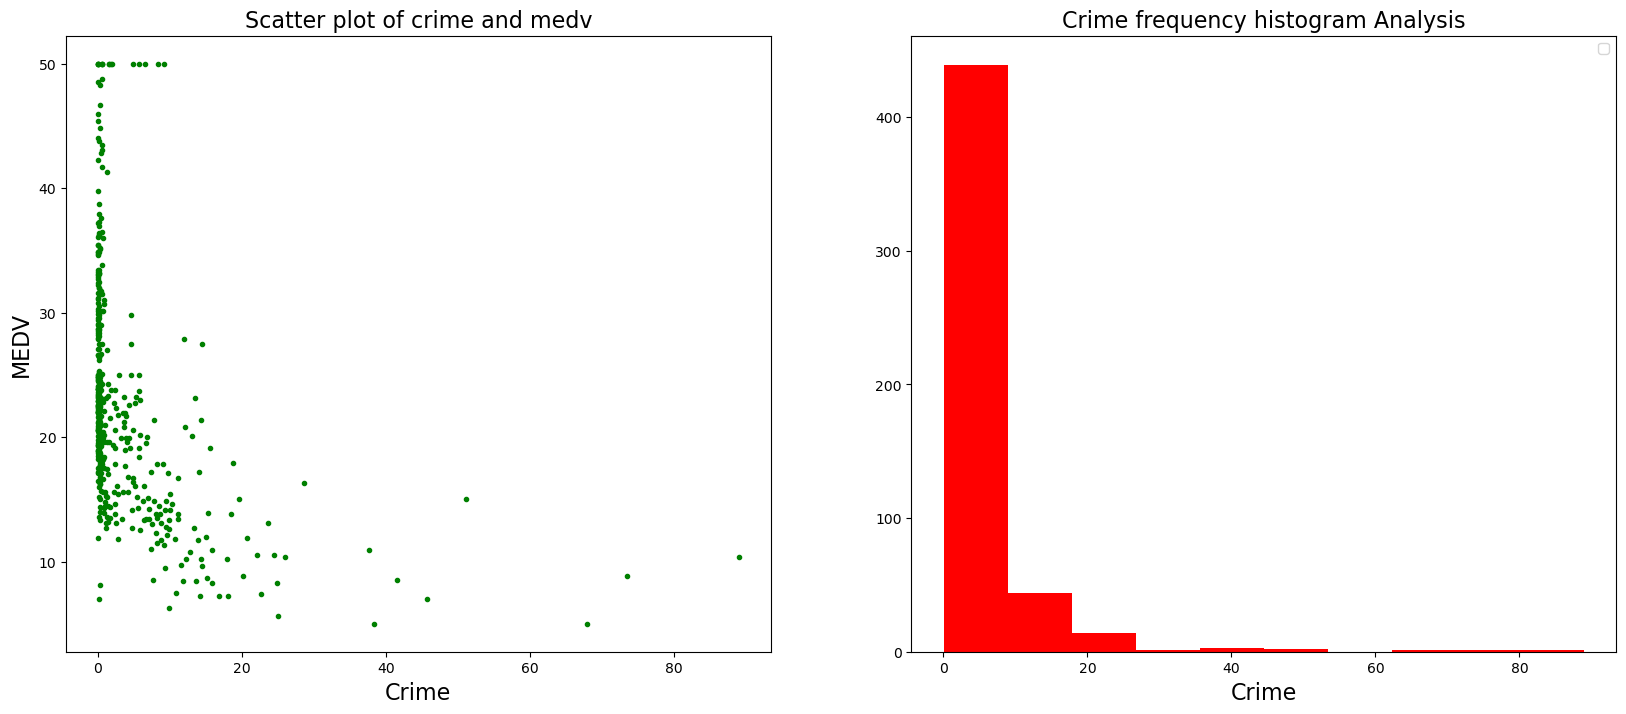

In [7]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
ax[0].scatter(df['crim'],df['medv'],marker='.',color='green',label="crime")
ax[0].set_xlabel('Crime',fontsize=16)
ax[0].set_ylabel('MEDV',fontsize=16)
ax[0].set_title('Scatter plot of crime and medv',fontsize=16)
plt.legend()

ax[1].hist(df['crim'],color='red')
ax[1].set_xlabel('Crime',fontsize=16)
ax[1].set_title('Crime frequency histogram Analysis',fontsize=16)
plt.show()

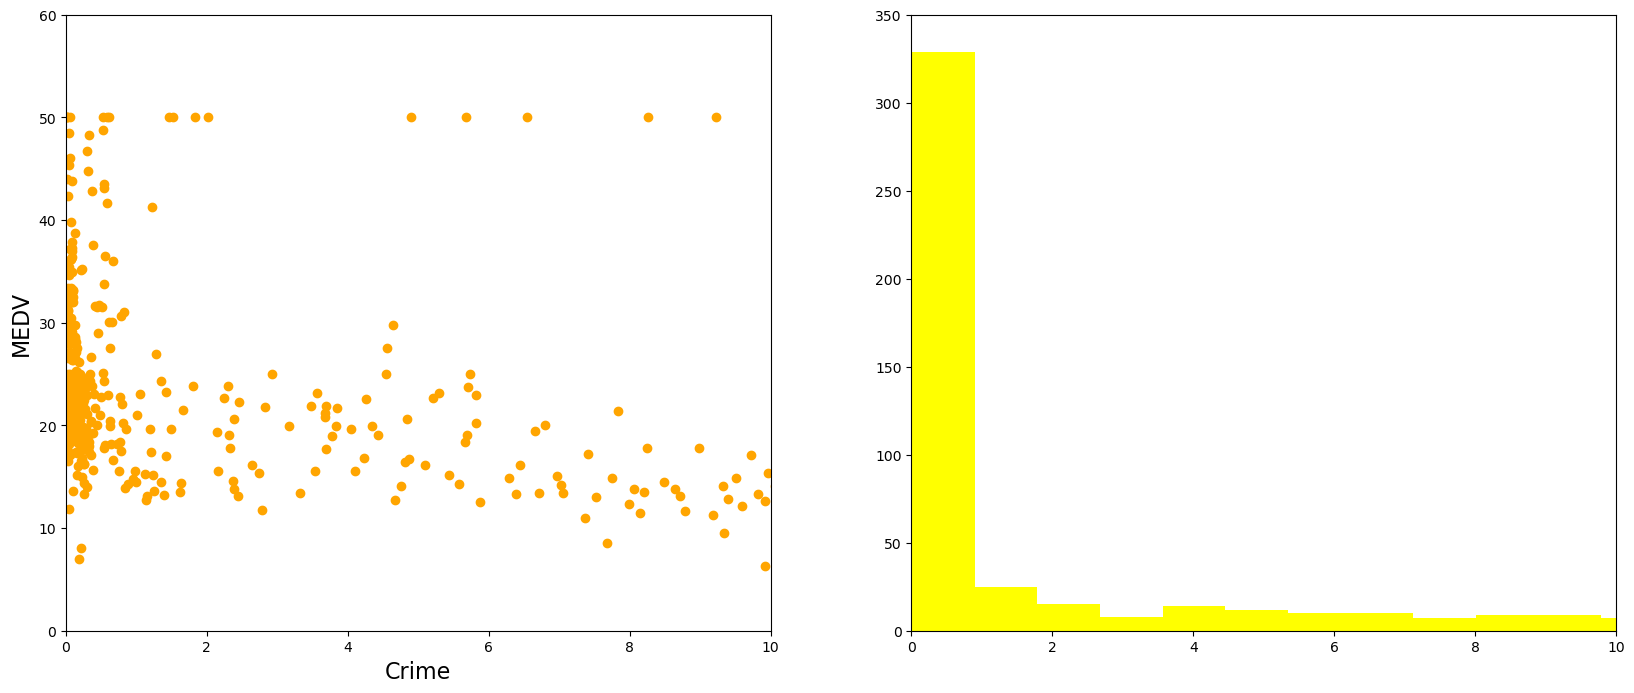

In [8]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
ax[0].scatter(df['crim'],df['medv'],marker='o',color='orange')
ax[0].set_xlabel('Crime',fontsize=16)
ax[0].set_ylabel('MEDV',fontsize=16)
ax[0].axis([0,10,0,60])
ax[1].hist(df['crim'],bins=100,color='yellow')
ax[1].axis([0,10,0,350])
plt.show()

In [9]:
df['zn'].value_counts()

zn
0.0      372
20.0      21
80.0      15
22.0      10
25.0      10
12.5      10
40.0       7
30.0       6
45.0       6
90.0       5
33.0       4
21.0       4
95.0       4
60.0       4
75.0       3
28.0       3
52.5       3
55.0       3
34.0       3
70.0       3
35.0       3
85.0       2
82.5       2
17.5       1
18.0       1
100.0      1
Name: count, dtype: int64

<Axes: >

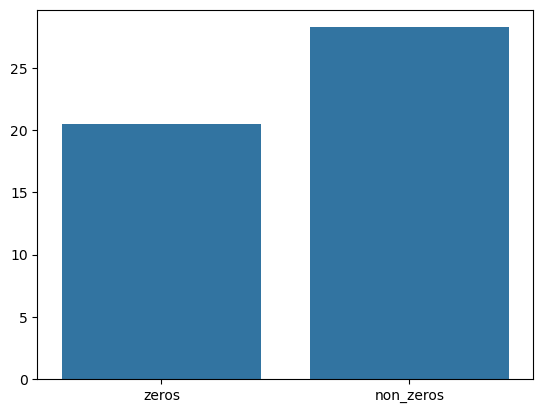

In [10]:
values=['zeros','non_zeros']
frequencies=[df[df['zn']==0]['medv'].mean(),df[df['zn']!=0]['medv'].mean()]
sns.barplot(x=values,y=frequencies)

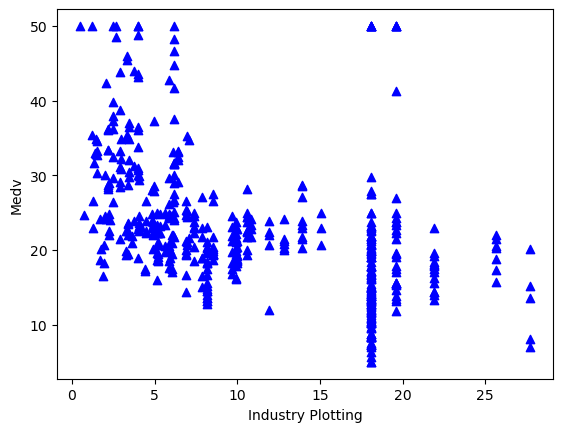

In [11]:
plt.scatter(df['indus'],df['medv'],marker='^',color='blue')
plt.xlabel("Industry Plotting")
plt.ylabel("Medv")
plt.show()

In [12]:
df['chas'].value_counts()

chas
0    471
1     35
Name: count, dtype: int64

In [13]:
values=['zeros','ones']
frequencies=[df[df['chas']==0].shape[0],df[df['chas']==1].shape[0]]
frequencies

[471, 35]

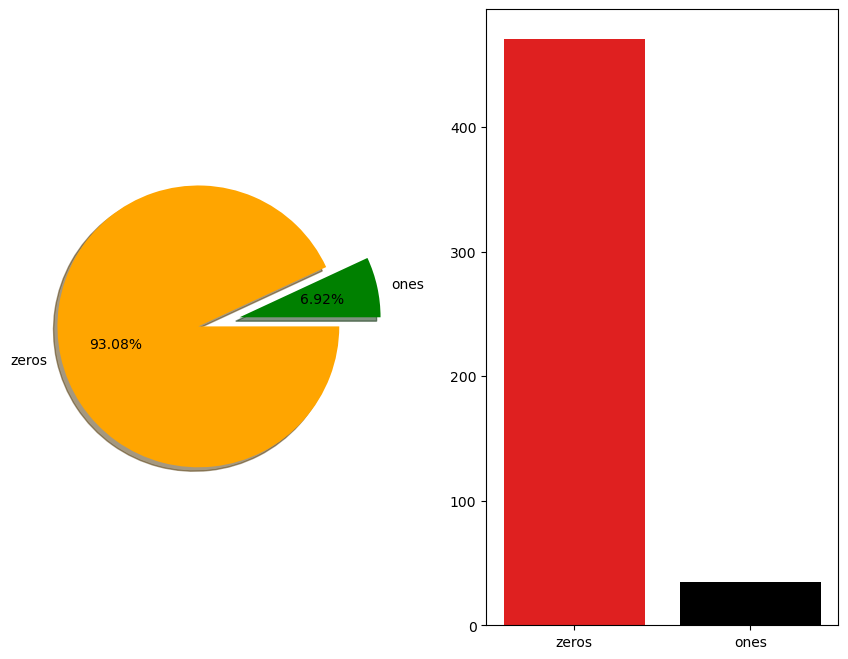

In [14]:
fig=plt.figure(figsize=(10,8))
fig.add_subplot(1,2,1)
plt.pie(frequencies,labels=values,colors=['orange','green'],
        counterclock=False,shadow=True,autopct="%.2f%%",explode=[0.3,0])
fig.add_subplot(1,2,2)
color=['red','black']
sns.barplot(x=values,y=frequencies,palette=color)
plt.show()

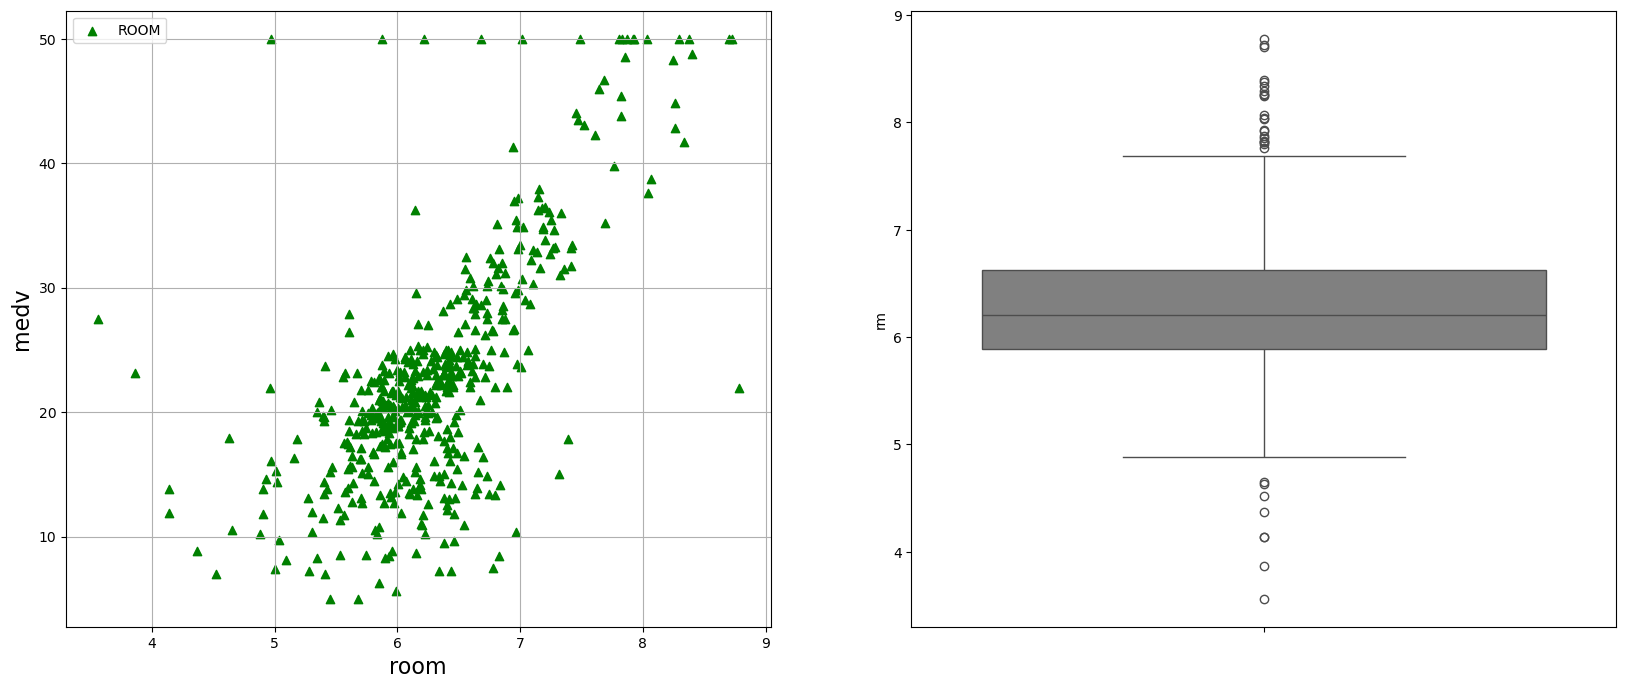

In [15]:
fig = plt.figure(figsize=(20,8))
fig.add_subplot(1,2,1)
plt.scatter(df['rm'],
            df['medv'],
            marker='^',
            color='green',
            label='ROOM'
            )
plt.xlabel('room',fontsize=16)
plt.ylabel('medv',fontsize=16)

plt.legend()
plt.grid()

fig.add_subplot(1,2,2)
sns.boxplot(y=df['rm'],color='gray')
plt.show()

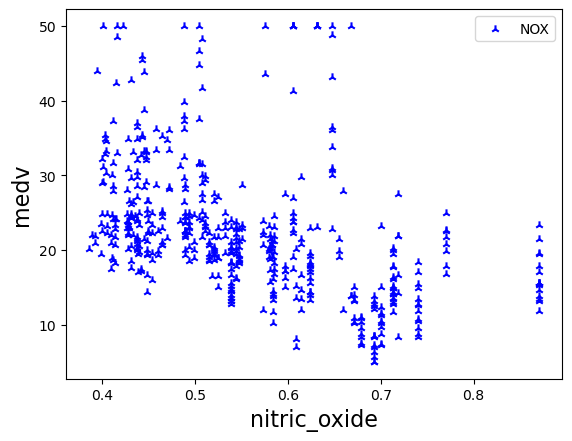

In [16]:
plt.scatter(df['nox'],df['medv'],color='blue',marker='2',label='NOX')
plt.xlabel("nitric_oxide",fontsize=16)
plt.ylabel("medv",fontsize=16)
plt.legend()
plt.show()

In [17]:
df['age'].value_counts()


age
100.0    43
87.9      4
97.9      4
98.8      4
96.0      4
         ..
85.9      1
66.6      1
54.2      1
61.1      1
78.9      1
Name: count, Length: 356, dtype: int64

<Axes: >

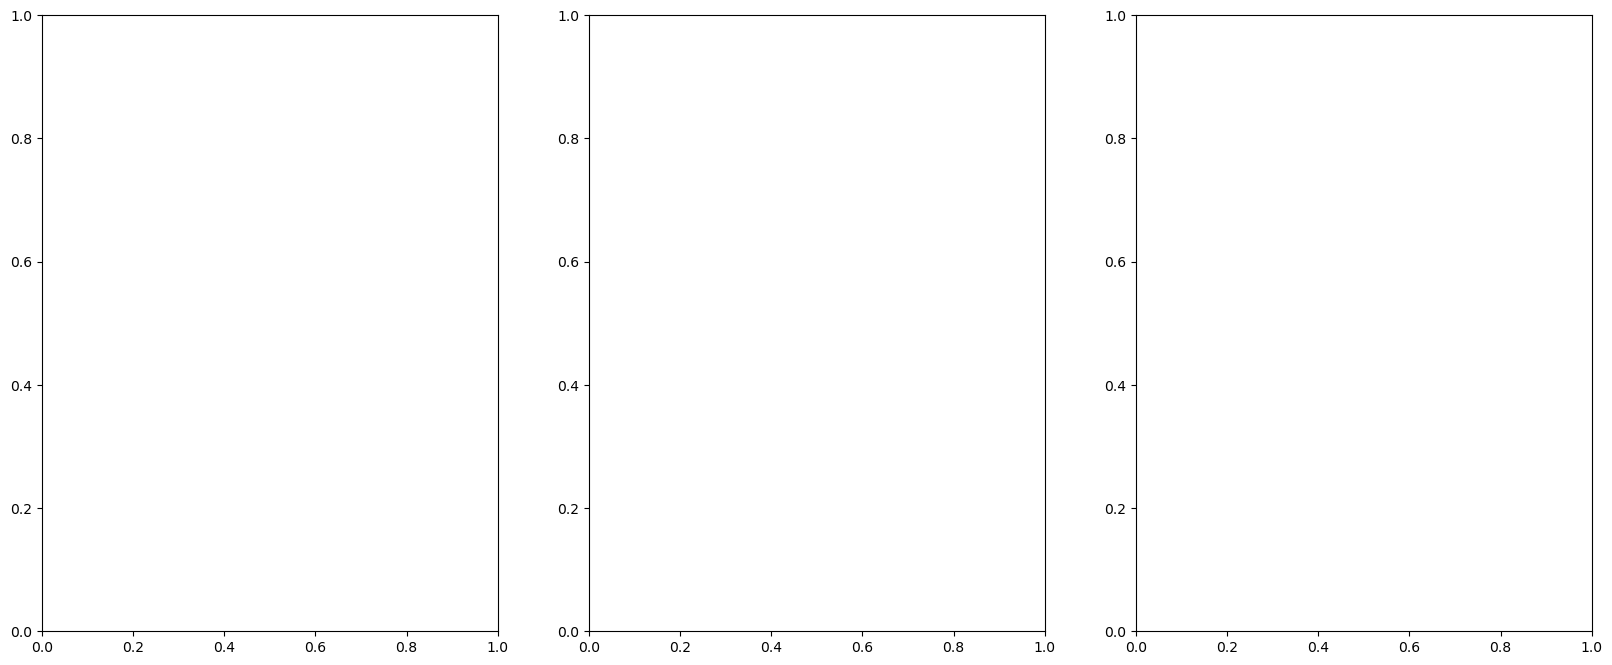

In [18]:
fig = plt.figure(figsize=(20,8))
fig.add_subplot(1,3,1)
fig.add_subplot(1,3,2)
fig.add_subplot(1,3,3)

# df['dis'].describe()

<Axes: xlabel='dis'>

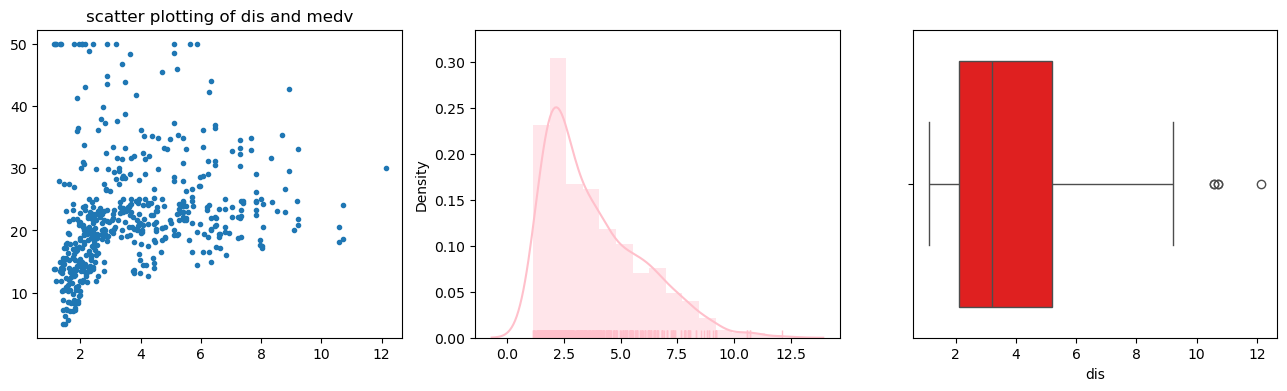

In [19]:
fig = plt.figure(figsize=(16,4))
fig.add_subplot(1,3,1)
plt.scatter(df['dis'],df['medv'],marker='.')
plt.title('scatter plotting of dis and medv')
fig.add_subplot(1,3,2)
sns.distplot(x=df['dis'],rug=True,color='pink')
fig.add_subplot(1,3,3)
sns.boxplot(x=df['dis'],color='red')

# df['dis'].describe()

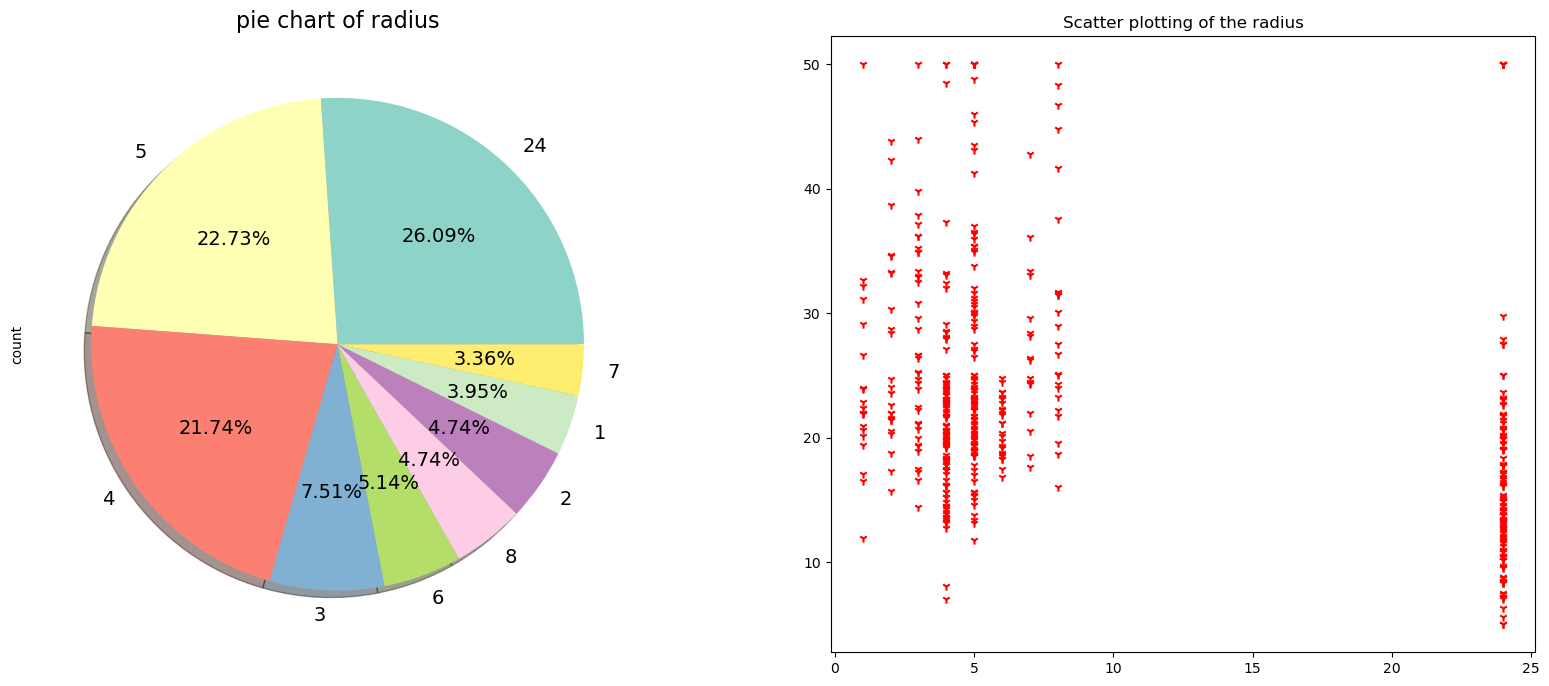

In [20]:
fig = plt.figure(figsize=(20,8))
fig.add_subplot(1,2,1)
plt.title("pie chart of radius",fontsize=16)
df['rad'].value_counts().plot(kind='pie',autopct='%.2f%%',cmap='Set3',
                              shadow=True,fontsize=14)

fig.add_subplot(1,2,2)

plt.title("Scatter plotting of the radius")
plt.scatter(df['rad'],df['medv'],marker='1',color='red')
plt.show()

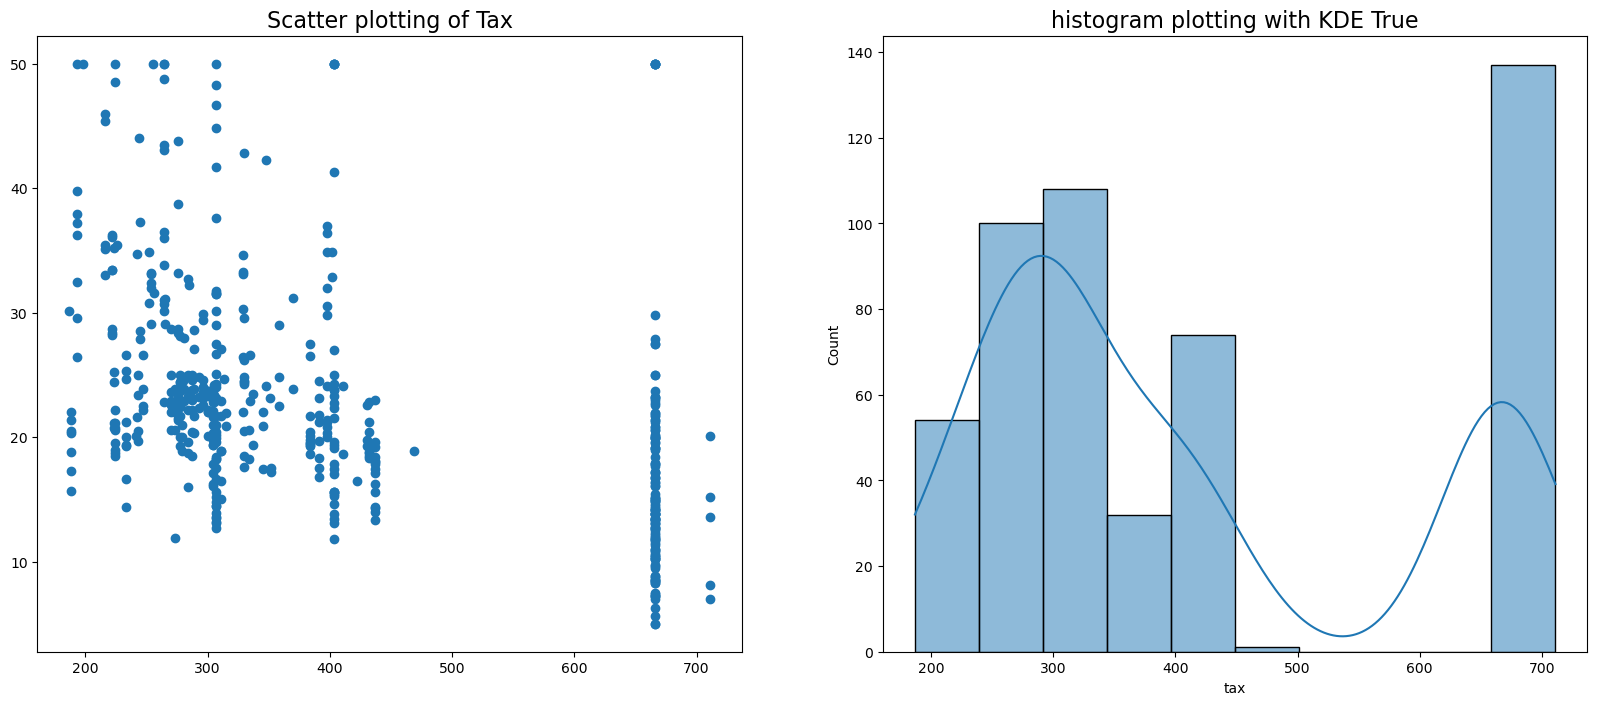

In [21]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
plt.title('Scatter Plotting of tax')
ax[0].set_title("Scatter plotting of Tax",fontsize=16)
ax[0].scatter(df["tax"],df["medv"],marker="o")
sns.histplot(df['tax'],kde=True,ax=ax[1])
ax[1].set_title("histogram plotting with KDE True",fontsize=16)
plt.show()


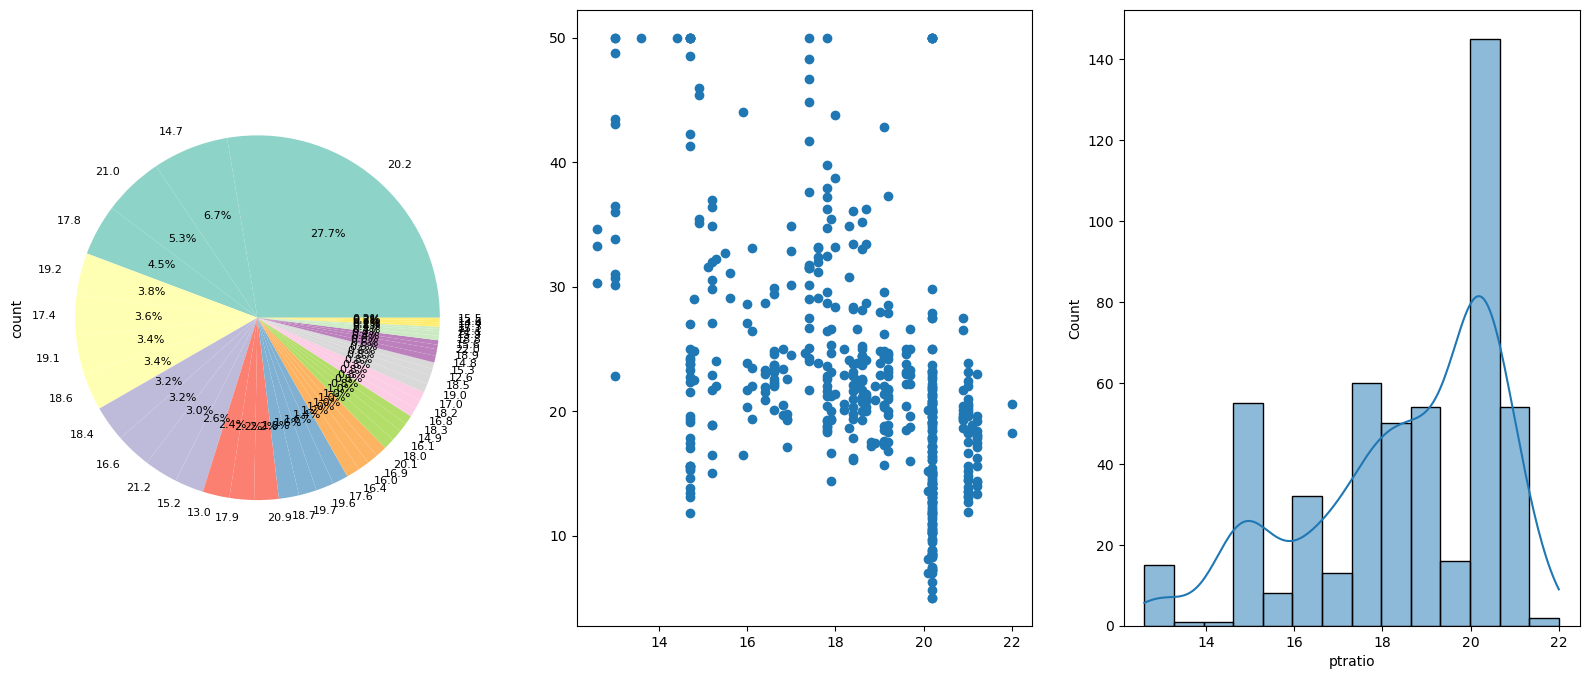

In [22]:
fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(20,8))
df['ptratio'].value_counts().plot(kind='pie',autopct='%.1f%%',colormap='Set3',ax=ax[0],fontsize=8)
ax[1].scatter(df['ptratio'],df['medv'],marker='o')
sns.histplot(df['ptratio'],kde=True,ax=ax[2])
plt.show()


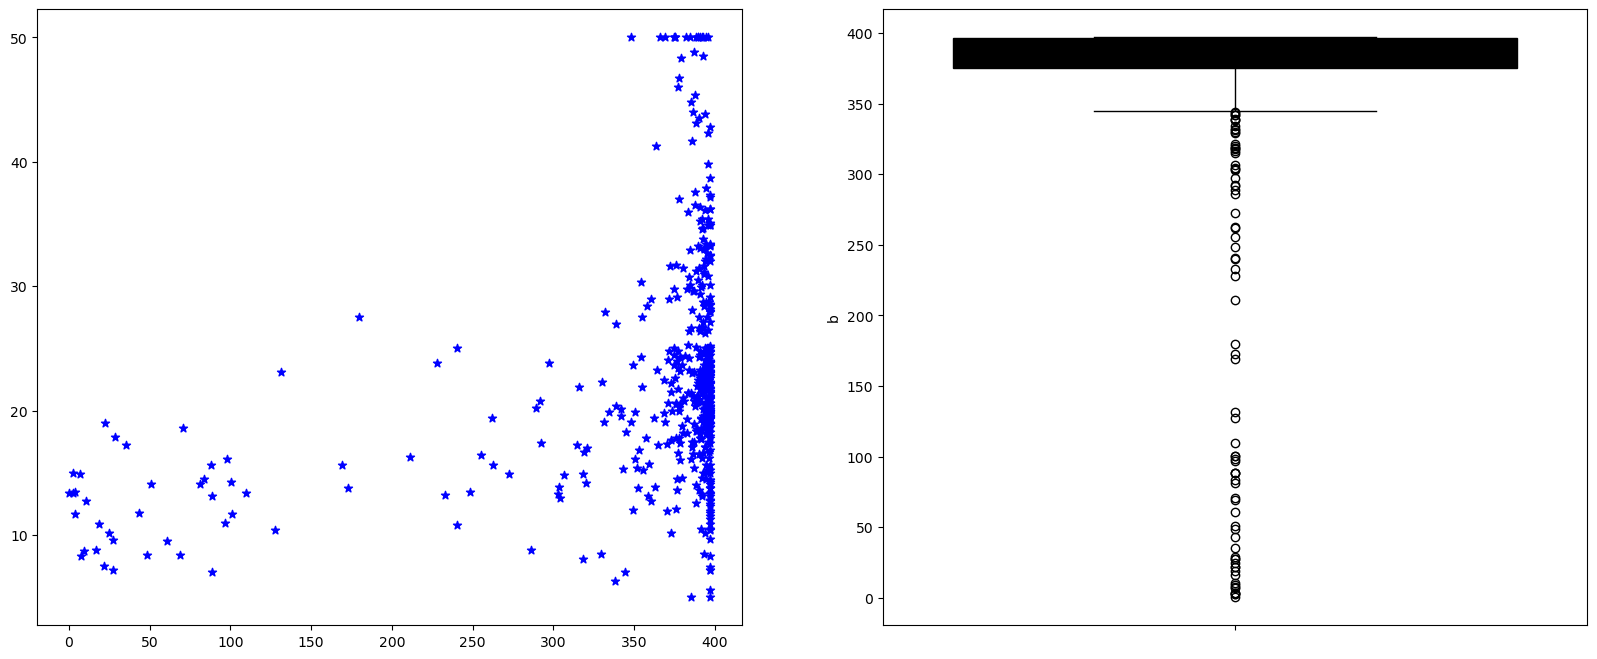

In [23]:
fig = plt.figure(figsize=(20,8))
fig.add_subplot(1,2,1)
plt.scatter(df['b'],df['medv'],marker='*',color="blue")
fig.add_subplot(1,2,2)
sns.boxplot(y=df['b'],color='black')
plt.show()

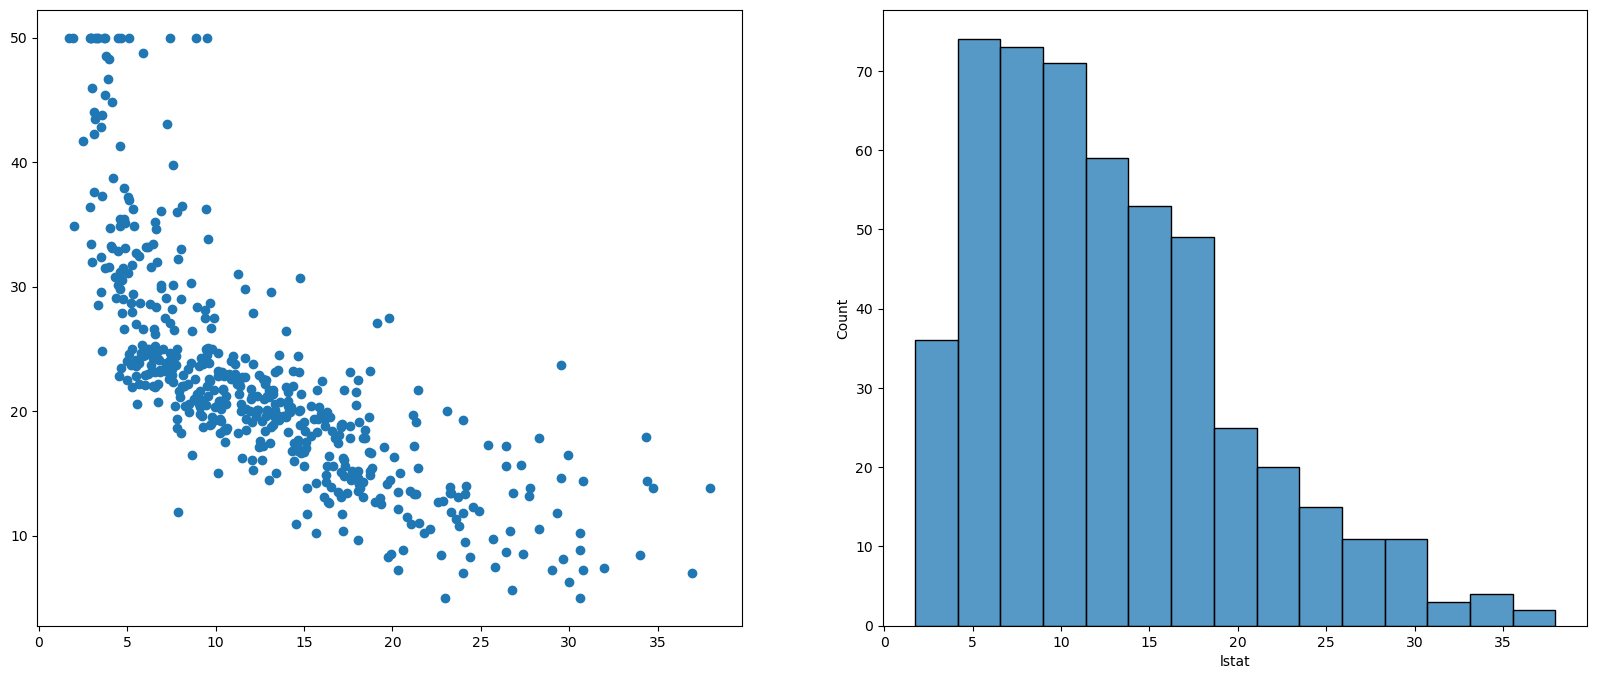

In [24]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
ax[0].scatter(df['lstat'],df['medv'],marker='o')
sns.histplot(df['lstat'],ax=ax[1])
plt.show()


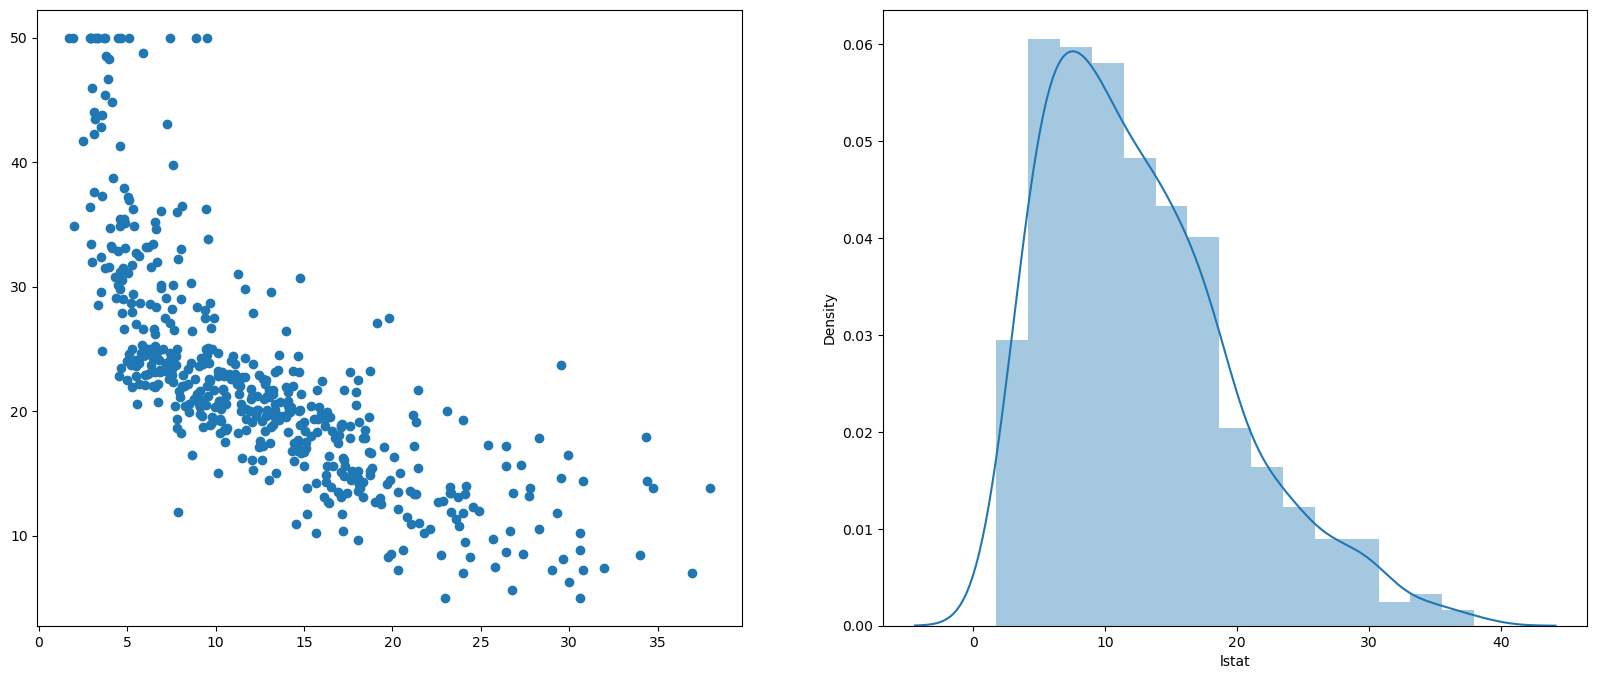

In [25]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(20,8))
ax[0].scatter(df['lstat'],df['medv'],marker='o')
sns.distplot(df['lstat'],ax=ax[1])
plt.show()


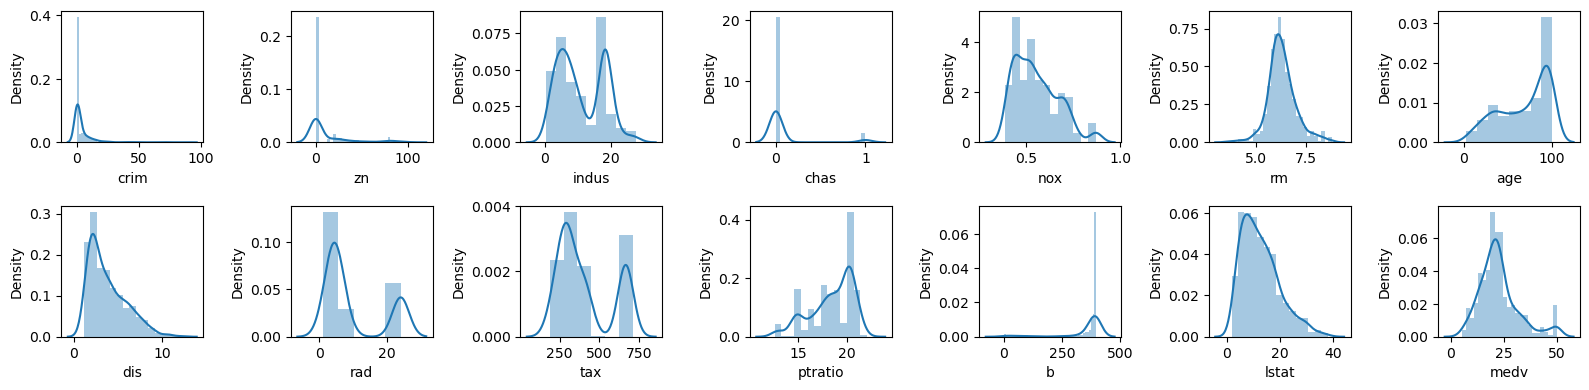

In [26]:
import warnings
warnings.filterwarnings("ignore")
rows=2
cols=7
fig,ax=plt.subplots(nrows=rows,ncols=cols,figsize=(16,4))
col=df.columns
index=0
for i in range(rows):
  for j in range(cols):
    sns.distplot(df[col[index]],ax=ax[i][j])
    index=index+1
plt.tight_layout()
plt.show()

In [27]:
cormat=df.corr()

In [28]:
cormat

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


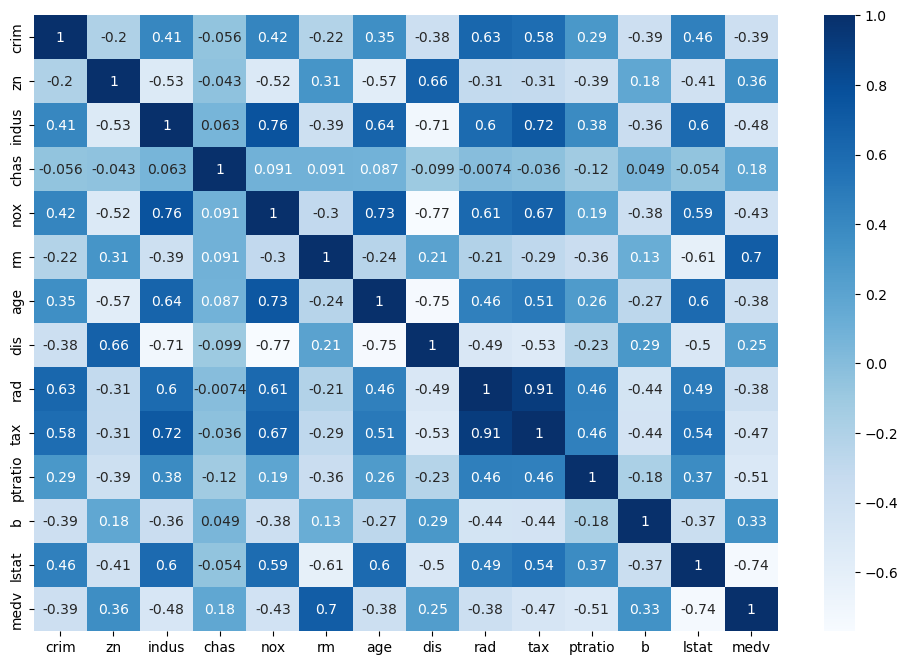

In [29]:
fig=plt.figure(figsize=(12,8))
fig.add_subplot(1,1,1)
sns.heatmap(cormat,annot=True,cmap='Blues')
plt.show()

In [30]:
def getcorrelatedfeature(corrdata,threshold):
    feature=[]
    values=[]
    for i,index in enumerate(corrdata.index):
        if(abs(corrdata[index])>threshold):
            feature.append(index)
            values.append(corrdata[index])
        df=pd.DataFrame(data=values,index=feature,columns=['corr_data'])
    return df

In [31]:
threshold=0.50
corr_value=getcorrelatedfeature(cormat['medv'],threshold)
corr_value

,corr_data
rm,0.695360
ptratio,-0.507787
lstat,-0.737663
medv,1.000000


In [32]:
correlated_data=df[corr_value.index]
correlated_data.head()

,rm,ptratio,lstat,medv
0,6.575,15.3,4.98,24.0
1,6.421,17.8,9.14,21.6
2,7.185,17.8,4.03,34.7
3,6.998,18.7,2.94,33.4
4,7.147,18.7,5.33,36.2


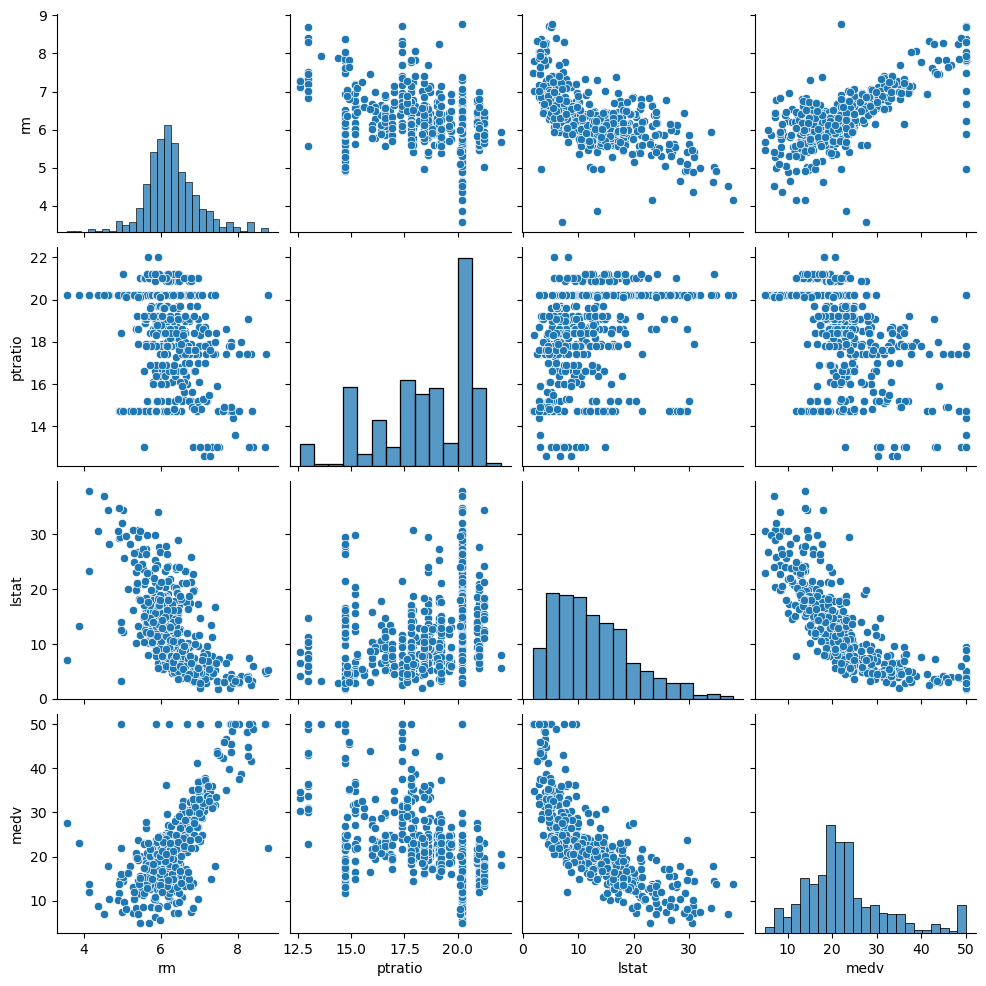

In [33]:
sns.pairplot(correlated_data)

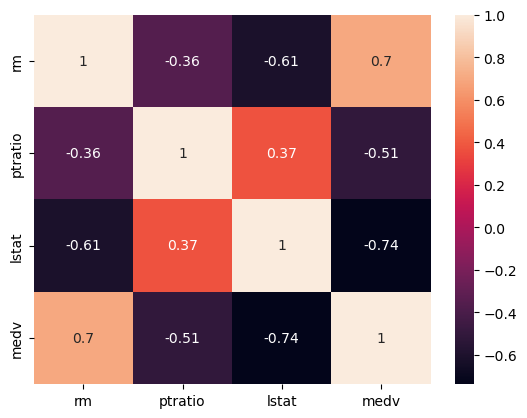

In [34]:
sns.heatmap(correlated_data.corr(),annot=True,annot_kws={'size':10})
plt.show()

In [35]:
correlated_data.columns

Index(['rm', 'ptratio', 'lstat', 'medv'], dtype='object')

In [36]:
x=correlated_data[['rm','ptratio','lstat']]
y=correlated_data['medv']

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((404, 3), (102, 3), (404,), (102,))

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
lin_reg=LinearRegression()

In [42]:
lin_reg.fit(x_train,y_train)

LinearRegression()

In [43]:
y_pred=lin_reg.predict(x_test)

In [44]:
result_df=pd.DataFrame(data=[y_pred,y_test],index=["predicted_value","actual_value"])
result_df.T.head()

,predicted_value,actual_value
0,26.718396,23.6
1,30.663291,32.4
2,16.426377,13.6
3,24.728708,22.8
4,18.342368,16.1


In [45]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [46]:
print("the MSE is",mean_squared_error(y_test,y_pred))
print("the mean absolute error",mean_absolute_error(y_test,y_pred))
print("the R2 score is",r2_score(y_test,y_pred)*100)

the MSE is 27.11495741558058
the mean absolute error 3.3325380783240974
the R2 score is 63.02528487272827


In [47]:
import pickle

In [48]:
with open("boston_project",'wb')as f:
    pickle.dump=(lin_reg,f)